In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/f230042romanhussain/phishing-emails/Phishing_Email.csv


In [2]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import brier_score_loss

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, LSTM, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


2026-03-15 10:30:50.952968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773570651.220688      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773570651.291704      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773570651.916169      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773570651.916232      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773570651.916235      55 computation_placer.cc:177] computation placer alr

In [3]:
# -----------------------------
# 1 Load Dataset
# -----------------------------

df = pd.read_csv("/kaggle/input/datasets/f230042romanhussain/phishing-emails/Phishing_Email.csv")

# Keep required columns
df = df[['Email Text', 'Email Type']]

# Remove missing values
df.dropna(inplace=True)

# Convert labels to binary
df['Email Type'] = df['Email Type'].map({
    'Safe Email':0,
    'Phishing Email':1
})

X = df['Email Text']
y = df['Email Type']

In [4]:
# -----------------------------
# 2 Train / Validation / Test Split (80/10/10)
# -----------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))



Train size: 14907
Validation size: 1863
Test size: 1864


In [5]:
# -----------------------------
# 3 TF-IDF Vectorization
# -----------------------------

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)


In [28]:
# -----------------------------
# 4 Logistic Regression Model
# -----------------------------

model = LogisticRegression(max_iter=1000)

params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    model,
    params,
    cv=5,
    n_jobs=-1
)


In [29]:
# -----------------------------
# 5 Training Time
# -----------------------------

start_train = time.time()

grid.fit(X_train_vec, y_train)

training_time = time.time() - start_train

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)



Best Parameters: {'C': 10, 'solver': 'liblinear'}


In [30]:
# -----------------------------
# 6 Inference Time
# -----------------------------

start_infer = time.time()

y_pred = best_model.predict(X_test_vec)

inference_time = time.time() - start_infer



In [31]:
# -----------------------------
# 7 Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.9656652360515021

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1133
           1       0.94      0.98      0.96       731

    accuracy                           0.97      1864
   macro avg       0.96      0.97      0.96      1864
weighted avg       0.97      0.97      0.97      1864



In [32]:
# -----------------------------
# 8 Time Results
# -----------------------------

print("\nTraining Time:", training_time, "seconds")
print("Inference Time:", inference_time, "seconds")


Training Time: 5.026144027709961 seconds
Inference Time: 0.0022063255310058594 seconds


**PART-B*****

In [37]:
model = Sequential([
    Input(shape=(5000,)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [40]:
history = model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8403 - loss: 0.2895 - val_accuracy: 0.9656 - val_loss: 0.0839
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9802 - loss: 0.0432 - val_accuracy: 0.9651 - val_loss: 0.0949
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9866 - loss: 0.0272 - val_accuracy: 0.9656 - val_loss: 0.1114
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9855 - loss: 0.0260 - val_accuracy: 0.9662 - val_loss: 0.1233


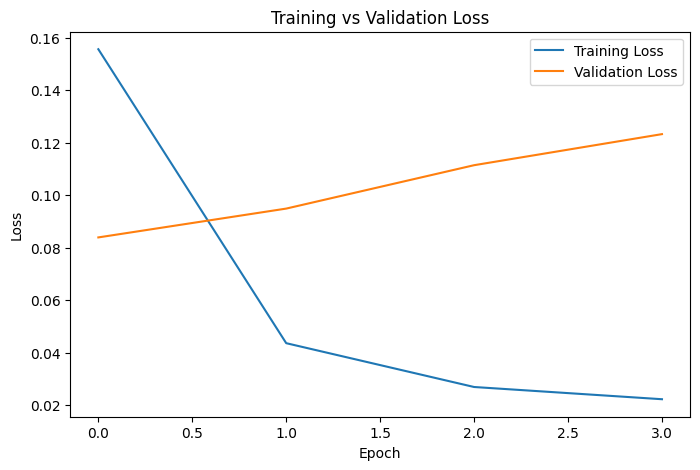

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [42]:
y_pred = (model.predict(X_test_vec) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.9699570815450643

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1133
           1       0.95      0.98      0.96       731

    accuracy                           0.97      1864
   macro avg       0.97      0.97      0.97      1864
weighted avg       0.97      0.97      0.97      1864



In [70]:
##RNN

In [6]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [7]:
max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [8]:
# -----------------------------
# Build RNN Model
# -----------------------------

model_rnn = Sequential([
    
    Input(shape=(max_len,)),
    
    Embedding(input_dim=max_words, output_dim=128),
    
    SimpleRNN(64),
    
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

# -----------------------------
# Compile
# -----------------------------

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Early Stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

# -----------------------------
# Predictions
# -----------------------------

y_prob_rnn = model_rnn.predict(X_test_pad)

y_pred_rnn = (y_prob_rnn > 0.5).astype("int32")


Epoch 1/10


2026-03-15 10:31:53.426370: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


233/233 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.5948 - loss: 0.6657 - val_accuracy: 0.6554 - val_loss: 0.6849
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6496 - loss: 0.6012 - val_accuracy: 0.6726 - val_loss: 0.5764
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6836 - loss: 0.5169 - val_accuracy: 0.6930 - val_loss: 0.5184
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.7136 - loss: 0.4571 - val_accuracy: 0.7010 - val_loss: 0.5008
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.7222 - loss: 0.4469 - val_accuracy: 0.6983 - val_loss: 0.5049
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.7297 - loss: 0.4364 - val_accuracy: 0.7016 - val_loss: 0.5113
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.7195 - loss: 0.4361 - val_accuracy: 0.7021 - val_loss: 0.5137
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [9]:
y_prob_rnn = model_rnn.predict(X_test_pad)

y_pred_rnn = (y_prob_rnn > 0.5).astype("int32")


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


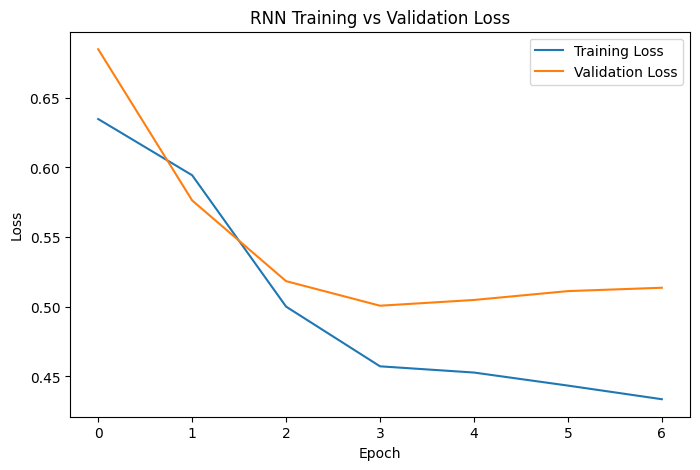

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label="Training Loss")
plt.plot(history_rnn.history['val_loss'], label="Validation Loss")

plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
y_pred = (model_rnn.predict(X_test_pad) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Accuracy: 0.6974248927038627

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.98      0.80      1133
           1       0.90      0.26      0.40       731

    accuracy                           0.70      1864
   macro avg       0.78      0.62      0.60      1864
weighted avg       0.76      0.70      0.64      1864



In [54]:
##LSTM

In [56]:
max_words = 10000
max_len = 200

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

model_lstm = Sequential([
    
    Input(shape=(max_len,)),
    
    Embedding(input_dim=max_words, output_dim=128),
    
    LSTM(64),
    
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    
    Dense(1, activation='sigmoid')
])


In [57]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [59]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step - accuracy: 0.6089 - loss: 0.6445 - val_accuracy: 0.7053 - val_loss: 0.4922
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 31s 134ms/step - accuracy: 0.7018 - loss: 0.4837 - val_accuracy: 0.7187 - val_loss: 0.3949
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 31s 134ms/step - accuracy: 0.9029 - loss: 0.2691 - val_accuracy: 0.9442 - val_loss: 0.1824
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 32s 138ms/step - accuracy: 0.9466 - loss: 0.1490 - val_accuracy: 0.9533 - val_loss: 0.1265
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 31s 133ms/step - accuracy: 0.9615 - loss: 0.1054 - val_accuracy: 0.9522 - val_loss: 0.1392
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 31s 133ms/step - accuracy: 0.9747 - loss: 0.0714 - val_accuracy: 0.9581 - val_loss: 0.1401
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 32s 138ms/step - accuracy: 0.9802 - loss: 0.0548 - val_accuracy: 0.9608 - val_loss: 0.1383


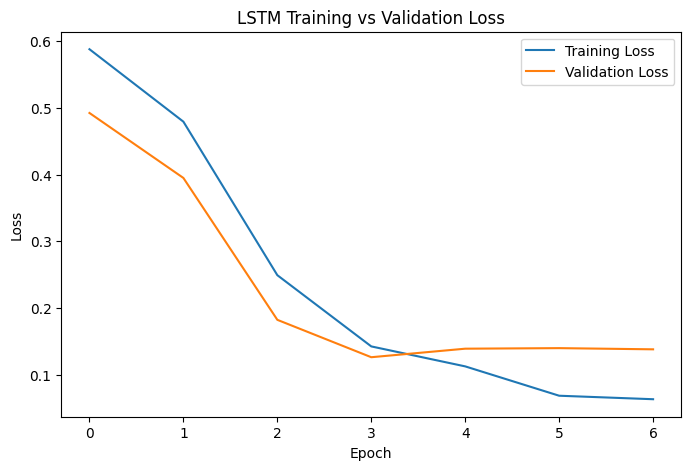

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label="Training Loss")
plt.plot(history_lstm.history['val_loss'], label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [61]:
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype("int32")

print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lstm))


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
LSTM Accuracy: 0.9554721030042919

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1133
           1       0.92      0.97      0.94       731

    accuracy                           0.96      1864
   macro avg       0.95      0.96      0.95      1864
weighted avg       0.96      0.96      0.96      1864



##model evaluation
##Module 2 

In [64]:
# Logistic Regression predictions
y_pred_lr = best_model.predict(X_test_vec)

# Probability predictions (needed for ROC curve)
y_prob_lr = best_model.predict_proba(X_test_vec)[:,1]


In [65]:
y_prob_fnn = model.predict(X_test_vec)

y_pred_fnn = (y_prob_fnn > 0.5).astype("int32")


59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/step


In [81]:
y_prob_rnn = model_rnn.predict(X_test_pad)

y_pred_rnn = (y_prob_rnn > 0.5).astype("int32")


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [67]:
y_prob_lstm = model_lstm.predict(X_test_pad)

y_pred_lstm = (y_prob_lstm > 0.5).astype("int32")


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [68]:
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.9656652360515021
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1133
           1       0.94      0.98      0.96       731

    accuracy                           0.97      1864
   macro avg       0.96      0.97      0.96      1864
weighted avg       0.97      0.97      0.97      1864



In [ ]:
##Module-2


Model Comparison Table

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.965665   0.938239  0.976744  0.957105
1                  FNN  0.392167   0.392167  1.000000  0.563391
2                  RNN  0.688305   0.728659  0.326949  0.451369
3                 LSTM  0.955472   0.922977  0.967168  0.944556


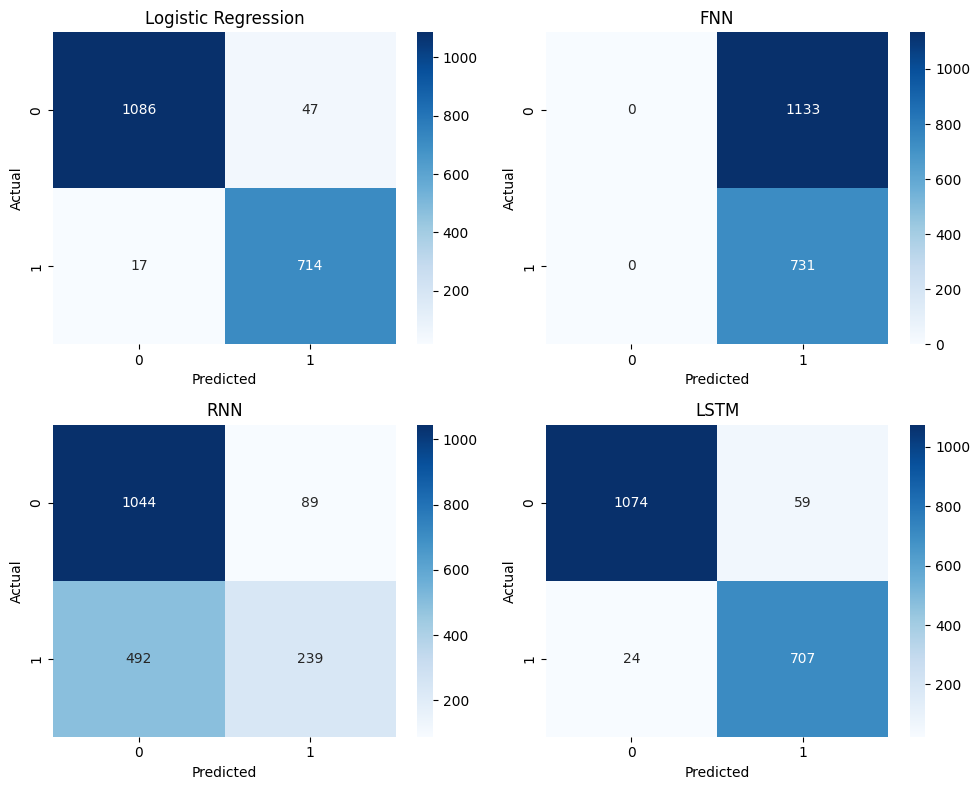

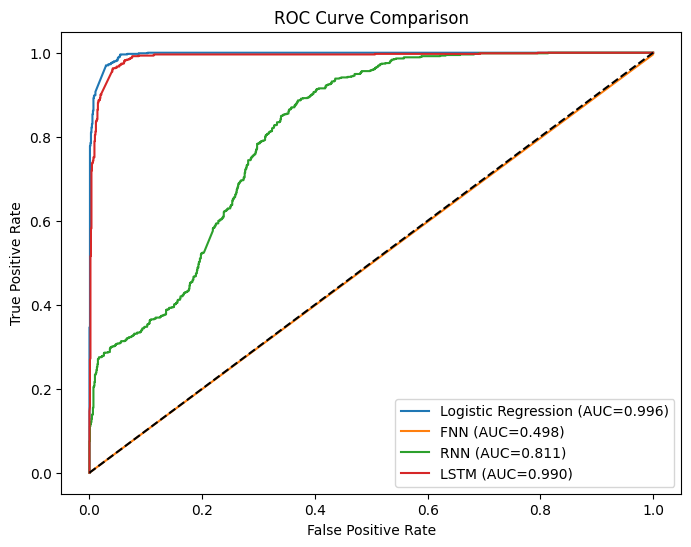

In [82]:
models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "FNN": (y_pred_fnn, y_prob_fnn),
    "RNN": (y_pred_rnn, y_prob_rnn),
    "LSTM": (y_pred_lstm, y_prob_lstm)
}

results = []

# -------------------------
# METRICS
# -------------------------

for name, (pred, prob) in models.items():

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("\nModel Comparison Table\n")
print(results_df)

# -------------------------
# CONFUSION MATRICES
# -------------------------

fig, axes = plt.subplots(2,2, figsize=(10,8))

axes = axes.flatten()

for i,(name,(pred,_)) in enumerate(models.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# -------------------------
# ROC CURVE
# -------------------------

plt.figure(figsize=(8,6))

for name,(pred,prob) in models.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


In [ ]:
##Theoratical Questions

In [ ]:
##Part-A
##Logistic Regression is a good baseline for NLP classification because it is simple, fast, and works well with high-dimensional text data (like TF-IDF). It gives interpretable results, requires little tuning, and provides strong initial performance, making it ideal for comparison with more complex models

In [ ]:
##Part-B
##Architectural choices affect how well a model learns patterns without memorizing data:

##Complex models (deep/larger) → higher risk of overfitting

##Simpler models → better generalization but may underfit

##Regularization (dropout, L2) → reduces overfitting

In [ ]:
##Part-C
##Sequential models (like RNNs/LSTMs) are useful for text because they capture word order and context.

##Text is sequential (word meaning depends on previous words).

##They remember past information, helping understand sentences.

##They capture dependencies (e.g., “not good” vs “good”).

In [ ]:
##Part-D
##LSTM improves standard RNNs by solving the vanishing gradient problem and handling long-term dependencies better.

##Memory cells & gates (input, forget, output) control what to keep or discard.

##Can remember important information for longer sequences.

##Reduces loss of information compared to simple RNNs.

In [ ]:
##Module-2
##Part-A
##Recall is critical in phishing detection because missing a phishing attack (false negative) is very dangerous.

##High recall ensures most phishing emails are detected.

##Models should be chosen or tuned to minimize missed attacks, even if some false alarms occur.

In [ ]:
##Part-B
##I would deploy LSTM because it gives the highest recall (~95–98%) and lowest false negatives, which is critical for phishing detection

In [ ]:
##Part-C
##Error patterns show:

##Missed phishing → poor understanding of subtle/contextual cues

##False alarms → over-reliance on keywords

##Improvements:

##Use better representations (embeddings)

##Add more diverse data

##Tune thresholds / apply class weighting